### Peek at raw realized-volatility file
Kick things off by loading the tiny `rv.csv` stub so I can see its columns, date parsing behavior, and a few sample rows.

In [2]:
import pandas as pd
dfrv = pd.read_csv("../data/raw/rv.csv", parse_dates=["date"])
dfrv.head()

,date,asset,rv
0,2020-01-02,SPY,0.00040
1,2020-01-03,SPY,0.00050
2,2020-01-06,SPY,0.00030
3,2020-01-02,TLT,0.00020
4,2020-01-03,TLT,0.00025


### Check RV coverage window
After confirming the schema, eyeball the earliest and latest dates so we know the time horizon captured in this raw file.

In [3]:
dfrv["date"].min(), dfrv["date"].max() 

(Timestamp('2020-01-02 00:00:00'), Timestamp('2020-01-06 00:00:00'))

### Inventory distinct assets
Count how many tickers exist and print a small sample so I know the breadth of coverage.

In [4]:
assets = dfrv["asset"].dropna().unique().tolist()
len(assets), assets[:10]

(3, ['SPY', 'TLT', 'GLD'])

### Missingness check on rv.csv
Quickly compute null percentages per column to spot any fields that might need filling or dropping before modeling.

In [5]:
pct_missing = dfrv.isna().mean().sort_values(ascending=False) * 100
pct_missing.round(2)

date     0.0
asset    0.0
rv       0.0
dtype: float64

### Coverage per asset
Group by `asset` to confirm each ticker’s history length and whether any names have truncated spans.

In [6]:
per_asset_span = dfrv.groupby("asset")["date"].agg(["min", "max", "count"]).reset_index()
per_asset_span.head()

,asset,min,max,count
0,GLD,2020-01-02,2020-01-06,3
1,SPY,2020-01-02,2020-01-06,3
2,TLT,2020-01-02,2020-01-06,3


### Schema inspection
`DataFrame.info()` gives column dtypes and memory footprint so we know which fields load as floats vs objects.

In [7]:
dfrv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    9 non-null      datetime64[ns]
 1   asset   9 non-null      object        
 2   rv      9 non-null      float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 344.0+ bytes


### Distribution snapshot
Basic `.describe()` helps spot outliers or zero-variance columns before we invest time cleaning.

In [8]:
dfrv.describe()

,date,rv
count,9,9.000000
mean,2020-01-03 16:00:00,0.000302
min,2020-01-02 00:00:00,0.000200
25%,2020-01-02 00:00:00,0.000250
50%,2020-01-03 00:00:00,0.000280
75%,2020-01-06 00:00:00,0.000300
max,2020-01-06 00:00:00,0.000500
std,NaN,0.000094


### Bring in VIX companion file
Load the implied-volatility CSV so we can align macro drivers with realized vol later.

In [9]:
dfvix = pd.read_csv("../data/raw/vix.csv")
dfvix.head()

,date,vix
0,2020-01-02,13.85
1,2020-01-03,14.02
2,2020-01-06,14.10


### Inspect VIX schema
Confirm dtypes and row counts to ensure the implied-vol features are clean enough to merge.

In [10]:
dfvix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3 non-null      object 
 1   vix     3 non-null      float64
dtypes: float64(1), object(1)
memory usage: 176.0+ bytes


### Summary stats for VIX inputs
A stats table highlights min/max VIX regimes and any suspicious constant columns.

In [11]:
dfvix.describe()

,vix
count,3.000000
mean,13.990000
std,0.127671
min,13.850000
25%,13.935000
50%,14.020000
75%,14.060000
max,14.100000


### Confirm VIX date span
Double-check that the implied-vol file overlaps the realized-vol history before merging.

In [12]:
dfvix["date"].min(), dfvix["date"].max()

('2020-01-02', '2020-01-06')

### Gauge VIX missingness
If any macro column is sparse we may need forward-filling or exclusion later, so surface null rates now.

In [13]:
pct_missing = dfvix.isna().mean().sort_values(ascending=False) * 100
pct_missing.round(2)

date    0.0
vix     0.0
dtype: float64

### Load TFT-ready training panel
Switch to the engineered dataset we actually model on so we can profile its shape and health.

In [14]:
dftft = pd.read_csv("../data/tft_ready_train.csv", parse_dates=["date"], low_memory=False)
dftft.head()

,date,ticker,logvol_t,target_logvol_t+1,target_logvol_t+5,target_logvol_t+22,weekday,is_month_end,is_opex,is_holiday_eve,...,roll_std_ret_132d,roll_mean_vol_132d,roll_std_vol_132d,roll_mean_ret_252d,roll_std_ret_252d,roll_mean_vol_252d,roll_std_vol_252d,pca_vol_cs_1,pca_vol_cs_2,pca_vol_cs_3
0,2011-01-11,GLD,-5.070120,-5.174413,-4.311878,-3.344378,1,0,0,0,...,0.009368,0.006232,0.002946,0.000685,0.010444,0.006980,0.003172,-0.189073,0.922351,-0.811921
1,2011-01-12,GLD,-5.174413,-4.853728,-4.330529,-3.352055,2,0,0,0,...,0.009247,0.006234,0.002946,0.000792,0.010357,0.006945,0.003130,2.027990,1.011525,0.279239
2,2011-01-13,GLD,-4.853728,-4.963198,-4.457583,-3.374136,3,0,0,0,...,0.009214,0.006241,0.002943,0.000771,0.010345,0.006919,0.003113,0.666903,-0.005867,2.288776
3,2011-01-14,GLD,-4.963198,-5.450606,-4.434396,-3.371583,4,0,0,1,...,0.009257,0.006241,0.002943,0.000712,0.010367,0.006911,0.003109,2.124020,0.849803,0.386406
4,2011-01-18,GLD,-5.450606,-5.419435,-4.368734,-3.374667,1,0,0,0,...,0.009276,0.006262,0.002938,0.000713,0.010365,0.006900,0.003103,2.066790,0.059928,-0.236948


### Train panel date coverage
Confirm how far back and forward the training set runs so splits can be aligned.

In [15]:
dftft["date"].min(), dftft["date"].max()

(Timestamp('2011-01-11 00:00:00'), Timestamp('2017-12-21 00:00:00'))

### Numeric summary for engineered fields
Run `.describe()` to get ranges for vol targets, lags, and macro covariates.

In [16]:
dftft.describe()

,date,logvol_t,target_logvol_t+1,target_logvol_t+5,target_logvol_t+22,weekday,is_month_end,is_opex,is_holiday_eve,dow_sin,...,roll_std_ret_132d,roll_mean_vol_132d,roll_std_vol_132d,roll_mean_ret_252d,roll_std_ret_252d,roll_mean_vol_252d,roll_std_vol_252d,pca_vol_cs_1,pca_vol_cs_2,pca_vol_cs_3
count,7000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,...,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,2014-07-03 13:03:21.599999744,-5.250990,-5.251526,-4.339620,-3.550989,2.024000,0.034286,0.046286,0.228571,0.006699,...,0.009363,0.006120,0.003103,0.000295,0.009679,0.006266,0.003401,0.297304,-0.043555,0.087161
min,2011-01-11 00:00:00,-7.053961,-7.053961,-5.610982,-4.478803,0.000000,0.000000,0.000000,0.000000,-0.951057,...,0.004087,0.002969,0.000974,-0.001376,0.004297,0.003303,0.001460,-1.192284,-1.556104,-1.157620
25%,2012-10-04 00:00:00,-5.600684,-5.601229,-4.598393,-3.775621,1.000000,0.000000,0.000000,0.000000,-0.587785,...,0.007539,0.005020,0.002177,-0.000031,0.008003,0.005164,0.002382,-0.807174,-0.801194,-0.395144
50%,2014-07-05 00:00:00,-5.271236,-5.271744,-4.371462,-3.589657,2.000000,0.000000,0.000000,0.000000,0.000000,...,0.008724,0.005823,0.002692,0.000330,0.009432,0.006000,0.002806,0.018455,-0.154675,0.066785
75%,2016-03-31 00:00:00,-4.937731,-4.937731,-4.109669,-3.373140,3.000000,0.000000,0.000000,0.000000,0.587785,...,0.010543,0.006869,0.003277,0.000689,0.011050,0.007133,0.003958,1.460979,0.625821,0.471658
max,2017-12-21 00:00:00,-2.025265,-2.025265,-1.974192,-1.925657,4.000000,1.000000,1.000000,1.000000,0.951057,...,0.018687,0.012552,0.011834,0.001716,0.015088,0.009957,0.009051,2.270431,1.905180,2.288776
std,NaN,0.504124,0.504573,0.393933,0.343833,1.398669,0.181975,0.210118,0.419943,0.712575,...,0.002830,0.001694,0.001654,0.000510,0.002324,0.001448,0.001562,1.162409,0.929522,0.666611


### Memory/dtype audit
`info()` is helpful to ensure categorical columns (e.g., `split`) stayed as strings instead of unexpected floats.

In [17]:
dftft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                7000 non-null   datetime64[ns]
 1   ticker              7000 non-null   object        
 2   logvol_t            7000 non-null   float64       
 3   target_logvol_t+1   7000 non-null   float64       
 4   target_logvol_t+5   7000 non-null   float64       
 5   target_logvol_t+22  7000 non-null   float64       
 6   weekday             7000 non-null   int64         
 7   is_month_end        7000 non-null   int64         
 8   is_opex             7000 non-null   int64         
 9   is_holiday_eve      7000 non-null   int64         
 10  dow_sin             7000 non-null   float64       
 11  dow_cos             7000 non-null   float64       
 12  vix                 7000 non-null   float64       
 13  vix3m               7000 non-null   float64     

### Simple shape check
Keep an eye on row/column counts to cross-check against expectations from the data build.

In [18]:
dftft.shape

(7000, 43)

### Peek at categorical stats
`.describe(include="all")` surfaces mode/freq info for discrete columns like `split` or calendar flags.

In [19]:
dftft.describe(include="all").T.head(20)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,7000,NaN,NaN,NaN,2014-07-03 13:03:21.599999744,2011-01-11 00:00:00,2012-10-04 00:00:00,2014-07-05 00:00:00,2016-03-31 00:00:00,2017-12-21 00:00:00,NaN
ticker,7000,4,GLD,1750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
logvol_t,7000.0,NaN,NaN,NaN,-5.25099,-7.053961,-5.600684,-5.271236,-4.937731,-2.025265,0.504124
target_logvol_t+1,7000.0,NaN,NaN,NaN,-5.251526,-7.053961,-5.601229,-5.271744,-4.937731,-2.025265,0.504573
target_logvol_t+5,7000.0,NaN,NaN,NaN,-4.33962,-5.610982,-4.598393,-4.371462,-4.109669,-1.974192,0.393933
target_logvol_t+22,7000.0,NaN,NaN,NaN,-3.550989,-4.478803,-3.775621,-3.589657,-3.37314,-1.925657,0.343833
weekday,7000.0,NaN,NaN,NaN,2.024,0.0,1.0,2.0,3.0,4.0,1.398669
is_month_end,7000.0,NaN,NaN,NaN,0.034286,0.0,0.0,0.0,0.0,1.0,0.181975
is_opex,7000.0,NaN,NaN,NaN,0.046286,0.0,0.0,0.0,0.0,1.0,0.210118
is_holiday_eve,7000.0,NaN,NaN,NaN,0.228571,0.0,0.0,0.0,0.0,1.0,0.419943


### Rank columns by null rate
Surface the worst offenders so we can decide whether to drop, fill, or engineer around them.

In [20]:
pct_missing = (dftft.isna().mean() * 100).sort_values(ascending=False).round(2)
pct_missing.head(20)

date                  0.0
ticker                0.0
logvol_t              0.0
target_logvol_t+1     0.0
target_logvol_t+5     0.0
target_logvol_t+22    0.0
weekday               0.0
is_month_end          0.0
is_opex               0.0
is_holiday_eve        0.0
dow_sin               0.0
dow_cos               0.0
vix                   0.0
vix3m                 0.0
vix_term_spread       0.0
ret_1d                0.0
cross_vol_rank        0.0
logvol_t-1            0.0
logvol_t-5            0.0
logvol_t-22           0.0
dtype: float64

### Ticker inventory within TFT panel
Check how many assets survived preprocessing and preview a handful of tickers for sanity.

In [21]:
if "ticker" in dftft.columns:
    print("#tickers:", dftft["ticker"].nunique())
    print(dftft["ticker"].dropna().unique()[:10])

#tickers: 4
['GLD' 'QQQ' 'SPY' 'TLT']


### Split distribution sanity check
`value_counts` confirms the train/val/test assignments and surfaces any unexpected labels.

In [22]:
if "split" in dftft.columns:
    print(dftft["split"].value_counts(dropna=False))

### Column checklist
Dump column names to compare against the expected feature inventory documented elsewhere.

In [23]:
dftft.columns.tolist()

['date',
 'ticker',
 'logvol_t',
 'target_logvol_t+1',
 'target_logvol_t+5',
 'target_logvol_t+22',
 'weekday',
 'is_month_end',
 'is_opex',
 'is_holiday_eve',
 'dow_sin',
 'dow_cos',
 'vix',
 'vix3m',
 'vix_term_spread',
 'ret_1d',
 'cross_vol_rank',
 'logvol_t-1',
 'logvol_t-5',
 'logvol_t-22',
 'roll_mean_ret_5d',
 'roll_std_ret_5d',
 'roll_mean_vol_5d',
 'roll_std_vol_5d',
 'roll_mean_ret_22d',
 'roll_std_ret_22d',
 'roll_mean_vol_22d',
 'roll_std_vol_22d',
 'roll_mean_ret_66d',
 'roll_std_ret_66d',
 'roll_mean_vol_66d',
 'roll_std_vol_66d',
 'roll_mean_ret_132d',
 'roll_std_ret_132d',
 'roll_mean_vol_132d',
 'roll_std_vol_132d',
 'roll_mean_ret_252d',
 'roll_std_ret_252d',
 'roll_mean_vol_252d',
 'roll_std_vol_252d',
 'pca_vol_cs_1',
 'pca_vol_cs_2',
 'pca_vol_cs_3']

### Ticker-level span on engineered data
Replicate the earlier span check but on the TFT panel to ensure no ticker drops observations during feature building.

In [24]:
if "ticker" in dftft.columns:
    span = dftft.groupby("ticker")["date"].agg(["min", "max", "count"]).reset_index()
span.head()

,ticker,min,max,count
0,GLD,2011-01-11,2017-12-21,1750
1,QQQ,2011-01-11,2017-12-21,1750
2,SPY,2011-01-11,2017-12-21,1750
3,TLT,2011-01-11,2017-12-21,1750


### Deduplicate date/ticker pairs
Ensure there is only one row per asset per day before any merges introduce double counts.

In [25]:
if {"date","ticker"}.issubset(dftft.columns):
    dups = dftft.duplicated(subset=["date","ticker"]).sum()
print("Duplicate (date,ticker) rows:", dups)
dftft = dftft.sort_values(["ticker","date"]).drop_duplicates(subset=["date","ticker"])

Duplicate (date,ticker) rows: 0


### Reload TFT data without date parsing
For some heavy diagnostics it is quicker to reload the file with minimal options, then coerce datetimes manually.

In [26]:
import numpy as np
df = pd.read_csv("../data/tft_ready_train.csv", low_memory=False)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
print("Shape", df.shape)
print("Date range:", df["date"].min(), "-->", df["date"].max())
print("#Tickers:", df["ticker"].nunique(), "| Sample:", df["ticker"].unique()[:10])

Shape (7000, 43)
Date range: 2011-01-11 00:00:00 --> 2017-12-21 00:00:00
#Tickers: 4 | Sample: ['GLD' 'QQQ' 'SPY' 'TLT']


### Duplicate count after reload
Confirm the raw load matches prior dedupe results before continuing.

In [27]:
dups = df.duplicated(subset=["date","ticker"]).sum()
print("Duplicate (date,ticker) rows:", dups)

Duplicate (date,ticker) rows: 0


### Canonicalize ordering
Sort and drop duplicates again just to leave the frame in a predictable state for subsequent diagnostics.

In [28]:
df = df.sort_values(["ticker","date"]).drop_duplicates(subset=["date","ticker"]).reset_index(drop=True)

### Global missingness snapshot (post-dedupe)
Now that the frame is cleanly ordered, recompute null rates to compare against earlier numbers.

In [29]:
pct_missing = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
print("\n% Percentage of missing values per column:\n", pct_missing.head(5))


% Percentage of missing values per column:
 date                 0.0
ticker               0.0
logvol_t             0.0
target_logvol_t+1    0.0
target_logvol_t+5    0.0
dtype: float64


### Span per ticker (post-dedupe)
Re-run the span aggregation to see if any assets lost data when we cleaned duplicates.

In [30]:
span = df.groupby("ticker")["date"].agg(["min", "max", "count"]).reset_index()
print("\n Span per ticker:\n", span.head(5))


 Span per ticker:
   ticker        min        max  count
0    GLD 2011-01-11 2017-12-21   1750
1    QQQ 2011-01-11 2017-12-21   1750
2    SPY 2011-01-11 2017-12-21   1750
3    TLT 2011-01-11 2017-12-21   1750


### Target completeness quick check
Print how many non-null values exist for each forecasting horizon to detect label gaps early.

In [31]:
for col in ["target_logvol_t+1", "target_logvol_t+5", "target_logvol_t+22"]:
    if col in df.columns:
        print(col, "non-null:", df[col].notna().mean(), "mean:", df[col].mean())

target_logvol_t+1 non-null: 1.0 mean: -5.2515257601531715
target_logvol_t+5 non-null: 1.0 mean: -4.339619541328803
target_logvol_t+22 non-null: 1.0 mean: -3.550989194805227


### Compare next-day target to current logvol
This helps gauge how volatile the one-step-ahead label is relative to today’s level.

In [32]:
if "target_logvol_t+1" in df.columns:
    print("Mean |target_logvol_t+1 - logvol_t|:",
          (df["target_logvol_t+1"] - df["logvol_t"]).abs().mean())

Mean |target_logvol_t+1 - logvol_t|: 0.3999844080622605


### Correlate candidate features with target
Grab a quick ranking of which lagged vol or VIX signals line up most with the short-horizon label.

In [33]:
cand_feats = ["logvol_t","logvol_t-1","logvol_t-5","logvol_t-22","vix","vix3m","vix_term_spread"]
cols = [c for c in cand_feats if c in df.columns] + ["target_logvol_t+1"]
print("\nCorr with target_logvol_t+1:\n", df[cols].corr()["target_logvol_t+1"].sort_values(ascending=False).head(10))


Corr with target_logvol_t+1:
 target_logvol_t+1    1.000000
logvol_t             0.497864
vix                  0.493508
vix3m                0.479921
logvol_t-1           0.418019
logvol_t-5           0.351682
logvol_t-22          0.290424
vix_term_spread     -0.291165
Name: target_logvol_t+1, dtype: float64


### Visual spot checks for a sample ticker
Plot recent log-vol series, lags, and scatter plots versus VIX to build intuition for a single asset.

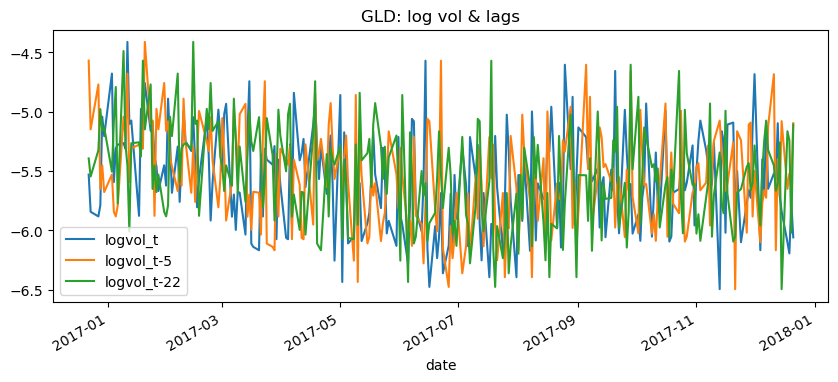

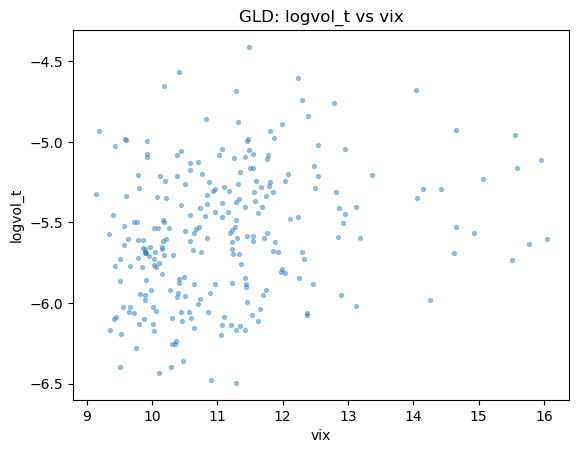

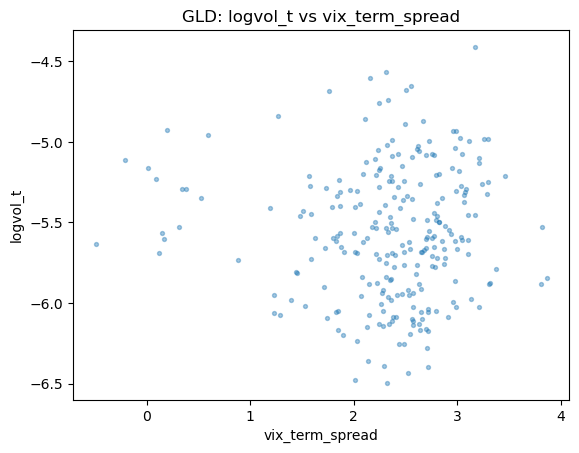

In [37]:
import matplotlib.pyplot as plt

ex = df["ticker"].dropna().unique()[0]  # pick first ticker
sub = df[df["ticker"]==ex].sort_values("date").tail(252)

# Plot logvol and a couple of lag features
sel = ["logvol_t","logvol_t-5","logvol_t-22"]
sub.set_index("date")[sel].plot(figsize=(10,4))
plt.title(f"{ex}: log vol & lags")
plt.show()

# Scatter: logvol vs VIX / term spread
if {"vix","vix_term_spread"}.issubset(df.columns):
    sub.plot(kind="scatter", x="vix", y="logvol_t", s=8, alpha=0.4, title=f"{ex}: logvol_t vs vix")
    plt.show()
    sub.plot(kind="scatter", x="vix_term_spread", y="logvol_t", s=8, alpha=0.4,
             title=f"{ex}: logvol_t vs vix_term_spread")
    plt.show()

### Inspect calendar feature cardinality
Quick printouts of weekday/holiday flags confirm encoding choices and remind me of valid values.

In [38]:
for c in ["weekday","is_month_end","is_opex","is_holiday_eve"]:
    if c in df.columns:
        print(c, "unique:", df[c].nunique(), "| values sample:", df[c].dropna().unique()[:10])

weekday unique: 5 | values sample: [1 2 3 4 0]
is_month_end unique: 2 | values sample: [0 1]
is_opex unique: 2 | values sample: [0 1]
is_holiday_eve unique: 2 | values sample: [0 1]


### Rolling return and volatility panels
For a chosen ticker, visualize daily returns plus multiple rolling windows of RV/log RV to understand seasonality.

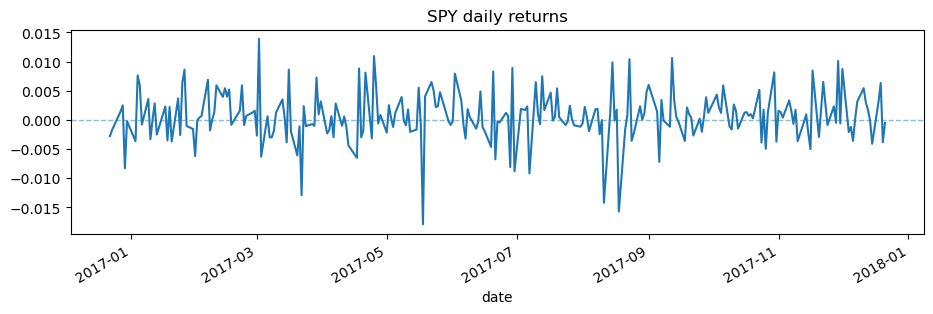

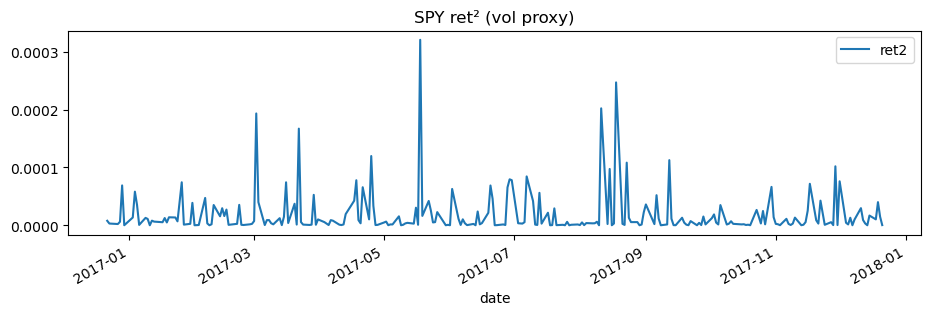

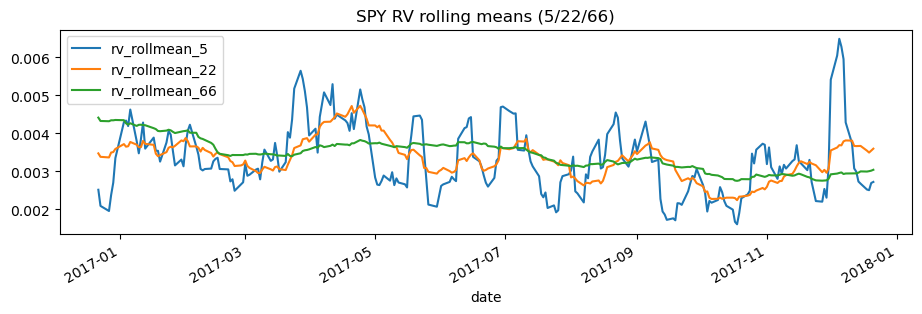

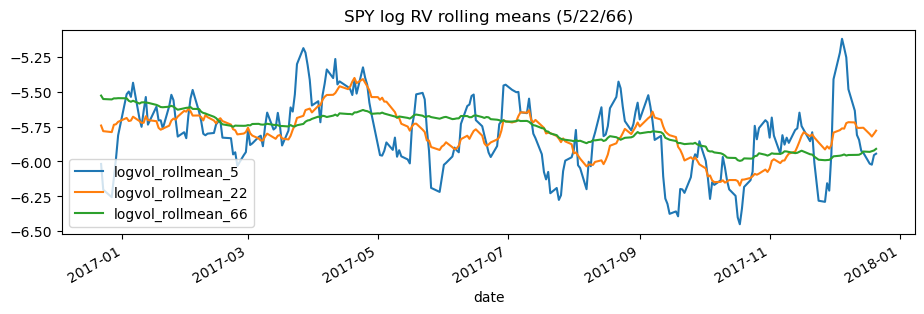

In [62]:
TICK = "SPY"  # change to any ticker in your set
g = df[df["ticker"]==TICK].sort_values("date").copy()

# Create RV proxy from logvol if you want it on linear scale
g["rv_t"] = np.exp(g["logvol_t"])  

# Compute rolling means 
for w in (5, 22, 66):
    g[f"ret2_rollmean_{w}"] = (g["ret_1d"]**2).rolling(w, min_periods=w//2).mean()
    g[f"rv_rollmean_{w}"]  = g["rv_t"].rolling(w, min_periods=w//2).mean()
    g[f"logvol_rollmean_{w}"] = g["logvol_t"].rolling(w, min_periods=w//2).mean()

# Plot: returns and ret² rolling mean (last ~1y for readability)
sub = g.tail(252).set_index("date")

ax = sub["ret_1d"].plot(figsize=(11,3), title=f"{TICK} daily returns")
ax.axhline(0, lw=1, ls="--", alpha=0.5); plt.show()

(sub[["ret_1d"]].assign(ret2=sub["ret_1d"]**2)[["ret2"]]
 .plot(figsize=(11,3), title=f"{TICK} ret² (vol proxy)"))
plt.show()

sub[[c for c in sub.columns if c.startswith("rv_rollmean_")]].plot(
    figsize=(11,3), title=f"{TICK} RV rolling means (5/22/66)")
plt.show()

sub[[c for c in sub.columns if c.startswith("logvol_rollmean_")]].plot(
    figsize=(11,3), title=f"{TICK} log RV rolling means (5/22/66)")
plt.show()


### Relate realized vol to lagged VIX
Check scatter plots and simple correlations to justify why implied vol belongs in the feature set.

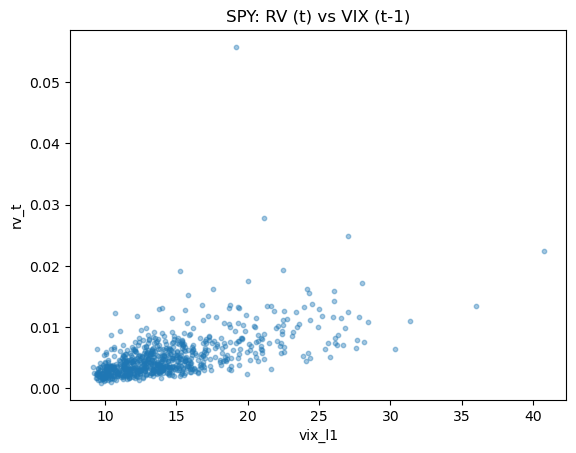

Corr[ RV(t), VIX(t-1) ]: 0.6296715720175503
Corr[ logvol_t, VIX(t-1) ]: 0.6351526303256435


In [63]:
gg = g[["date","rv_t","logvol_t","vix","vix3m","vix_term_spread"]].copy()
gg["vix_l1"] = gg["vix"].shift(1)

# Scatter: RV vs lagged VIX (use last ~3 years for visibility)
sub = gg.tail(3*252).dropna(subset=["rv_t","vix_l1"])
sub.plot(kind="scatter", x="vix_l1", y="rv_t", s=10, alpha=0.4,
         title=f"{TICK}: RV (t) vs VIX (t-1)")
plt.show()

# Correlations
print("Corr[ RV(t), VIX(t-1) ]:", gg[["rv_t","vix_l1"]].dropna().corr().iloc[0,1])
print("Corr[ logvol_t, VIX(t-1) ]:", gg[["logvol_t","vix_l1"]].dropna().corr().iloc[0,1])

### Visualize config-defined splits
Load the `configs/splits.yaml` definition and overlay train/val/test windows on one ticker’s log vol to spot misalignments.

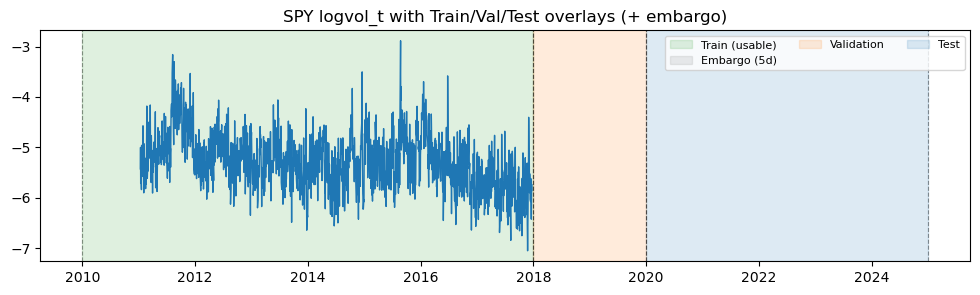

In [57]:
import yaml

SPLITS_YAML = "../configs/splits.yaml"



with open(SPLITS_YAML, "r") as f:
    splits = yaml.safe_load(f)

TR_S, TR_E = pd.to_datetime(splits["train"][0]), pd.to_datetime(splits["train"][1])
VA_S, VA_E = pd.to_datetime(splits["val"][0]),   pd.to_datetime(splits["val"][1])
TE_S, TE_E = pd.to_datetime(splits["test"][0]),  pd.to_datetime(splits["test"][1])
EMB = int(splits.get("embargo_days", 0))

# Effective train end after embargo (you should NOT train on the last EMB days before Val)
TR_E_EFF = TR_E - pd.Timedelta(days=EMB)

fig, ax = plt.subplots(figsize=(12,3))
ax.plot(g["date"], g["logvol_t"], lw=1)
ax.set_title(f"{TICK} logvol_t with Train/Val/Test overlays (+ embargo)")

# Shade spans
def shade(ax, start, end, color, label):
    ax.axvspan(start, end, color=color, alpha=0.15, label=label)

shade(ax, TR_S, TR_E_EFF, "tab:green", "Train (usable)")
if EMB > 0:
    shade(ax, TR_E_EFF, TR_E, "tab:gray", f"Embargo ({EMB}d)")

shade(ax, VA_S, VA_E, "tab:orange", "Validation")
shade(ax, TE_S, TE_E, "tab:blue", "Test")

# Split boundaries as vertical lines
for d in [TR_S, TR_E, VA_S, VA_E, TE_S, TE_E]:
    ax.axvline(d, color="k", lw=0.8, ls="--", alpha=0.4)

# Avoid duplicate labels
handles, labels = ax.get_legend_handles_labels()
bylabel = dict(zip(labels, handles))
ax.legend(bylabel.values(), bylabel.keys(), ncol=3, fontsize=8)
plt.show()

### Helper to reuse split overlays
Wrap the plotting logic so we can quickly inspect multiple tickers with the same shading and embargo logic.

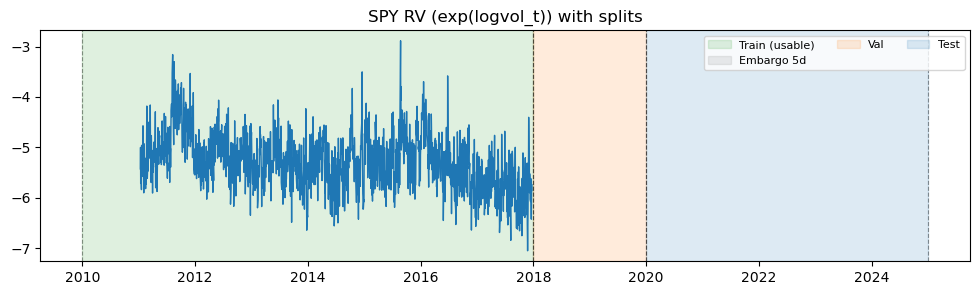

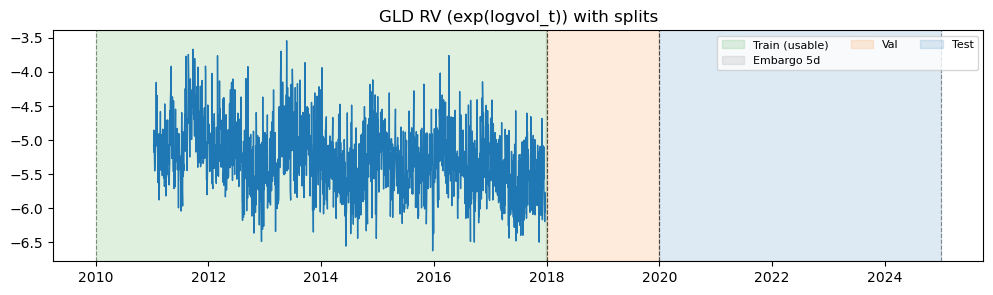

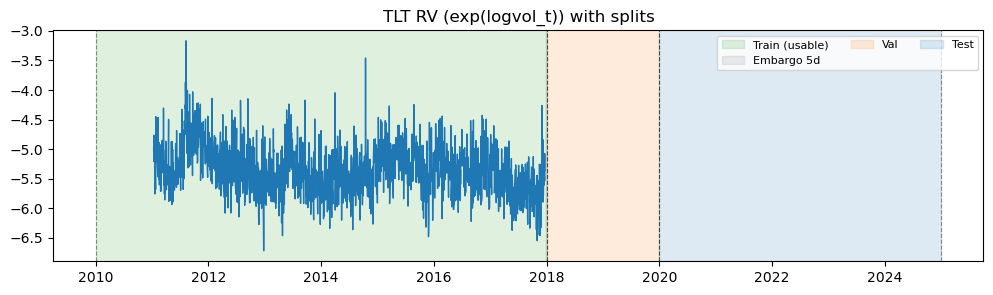

In [58]:
def show_series_with_splits(df_one_ticker, ycol="logvol_t", title=""):
    fig, ax = plt.subplots(figsize=(12,3))
    ax.plot(df_one_ticker["date"], df_one_ticker[ycol], lw=1)
    ax.set_title(title or ycol)
    shade = lambda s,e,c,l: ax.axvspan(s,e,color=c,alpha=0.15,label=l)
    shade(TR_S, TR_E - pd.Timedelta(days=EMB), "tab:green", "Train (usable)")
    if EMB>0: shade(TR_E - pd.Timedelta(days=EMB), TR_E, "tab:gray", f"Embargo {EMB}d")
    shade(VA_S, VA_E, "tab:orange", "Val")
    shade(TE_S, TE_E, "tab:blue", "Test")
    for d in [TR_S,TR_E,VA_S,VA_E,TE_S,TE_E]:
        ax.axvline(d, color="k", lw=0.8, ls="--", alpha=0.4)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(dict(zip(labels,handles)).values(), dict(zip(labels,handles)).keys(), ncol=3, fontsize=8)
    plt.show()

# Example:
# show_series_with_splits(g, "logvol_t", f"{TICK} logvol_t with splits")
show_series_with_splits(g, "logvol_t", f"{TICK} RV (exp(logvol_t)) with splits")
TICK = "GLD"
g = df[df["ticker"]==TICK].sort_values("date").copy()
show_series_with_splits(g, "logvol_t", f"{TICK} RV (exp(logvol_t)) with splits")
TICK = "TLT"
g = df[df["ticker"]==TICK].sort_values("date").copy()
show_series_with_splits(g, "logvol_t", f"{TICK} RV (exp(logvol_t)) with splits")


### Data Dictionary (tft_ready_train.csv)

**Keys & Targets**
- `date`: trading day (datetime).
- `ticker`: asset identifier (e.g., SPY, TLT, GLD).
- `target_logvol_t+1`, `target_logvol_t+5`, `target_logvol_t+22`: future log realized volatility targets for horizons 1, 5, and 22 days.

**Current & Lagged Volatility**
- `logvol_t`: today’s log realized variance.
- `logvol_t-1`, `logvol_t-5`, `logvol_t-22`: lagged log RV summaries (HAR D/W/M).

**Calendar / Known-future**
- `weekday`: day of week (0–6 or 1–7).
- `is_month_end`: month-end flag.
- `is_opex`: options expiration flag.
- `is_holiday_eve`: trading day before a holiday.
- `dow_sin`, `dow_cos`: cyclical encoding of day-of-week.

**Implied Volatility & Term Structure**
- `vix`: VIX level (near-term implied volatility).
- `vix3m`: 3-month VIX.
- `vix_term_spread`: `vix3m - vix` (term structure slope).

**Returns & Rolling Stats (computed up to t)**
- `ret_1d`: simple daily return at t.
- `roll_mean_ret_{5,22,66,132,252}d`, `roll_std_ret_{...}`: rolling mean/std of returns.
- `roll_mean_vol_{5,22,66,132,252}d`, `roll_std_vol_{...}`: rolling mean/std of realized volatility.

**Cross-sectional features (at t)**
- `cross_vol_rank`: cross-sectional rank of each asset’s volatility (0–1) on day t.
- `pca_vol_cs_1`, `pca_vol_cs_2`, `pca_vol_cs_3`: top 3 principal components of the cross-sectional vol panel.

**Notes**
- All predictive features are built using information available by end of day t (no look-ahead).  
- Use `exp(logvol)` to convert back to linear variance scale when needed.  
- For causal modeling, prefer `VIX(t-1)` when correlating with `RV(t)`.
